## 1. Setup and Data Loading

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk

# Download NLTK resources first
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [3]:
# Install required packages
!pip install pandas numpy matplotlib seaborn nltk textblob wordcloud

In [4]:
# Load adherence dataset with patient notes
df = pd.read_csv('../data/adherence_records.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few patient notes:")
df['patient_notes'].head()

Dataset Shape: (5000, 22)

Columns: ['patient_id', 'age', 'gender', 'education_level', 'income_level', 'living_situation', 'has_insurance', 'num_conditions', 'num_medications', 'medication_complexity', 'average_monthly_cost', 'adherence_score', 'is_adherent', 'is_non_adherent', 'primary_non_adherence_cause', 'secondary_causes', 'patient_notes', 'last_6_months_adherence', 'missed_doses_last_month', 'refill_on_time', 'using_reminder_app', 'last_visit_date']

First few patient notes:


0    Patient refills prescription on time consistently
1          Feeling better so stopped taking medication
2    Patient understands medication schedule and im...
3        Too many pills to manage, feeling overwhelmed
4    Patient reports taking medication regularly as...
Name: patient_notes, dtype: object

## 2. Text Preprocessing Pipeline

In [5]:
class TextPreprocessor:
    """Text preprocessing pipeline for patient notes"""
    
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        
        # Keep important medical words
        self.stop_words -= {'no', 'not', 'don', "don't", 'should', 'very', 'too'}
    
    def clean_text(self, text):
        """Basic text cleaning"""
        if pd.isna(text):
            return ""
        text = str(text).lower()
        return text
    
    def tokenize(self, text):
        """Tokenize text into words"""
        return word_tokenize(text)
    
    def remove_stopwords(self, tokens):
        """Remove stopwords but keep important ones"""
        return [token for token in tokens if token not in self.stop_words]
    
    def lemmatize(self, tokens):
        """Lemmatize tokens"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]
    
    def preprocess(self, text):
        """Full preprocessing pipeline"""
        text = self.clean_text(text)
        tokens = self.tokenize(text)
        tokens = [t for t in tokens if t.isalnum()]  # Remove punctuation
        tokens = self.remove_stopwords(tokens)
        tokens = self.lemmatize(tokens)
        return tokens

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Test preprocessing
sample_text = df['patient_notes'].iloc[0]
print(f"Original: {sample_text}")
print(f"\nProcessed: {preprocessor.preprocess(sample_text)}")

Original: Patient refills prescription on time consistently

Processed: ['patient', 'refill', 'prescription', 'time', 'consistently']

Processed: ['patient', 'refill', 'prescription', 'time', 'consistently']


In [6]:
# Apply preprocessing to all notes
# Ensure dataframe is available (load if missing)
if 'df' not in globals():
	try:
		df = pd.read_csv('../data/adherence_records.csv')
		print("Loaded df from ../data/adherence_records.csv")
	except Exception as e:
		raise RuntimeError("df is not defined and failed to load the CSV. Please run the data-loading cell or ensure the CSV path is correct.") from e

# Ensure preprocessor is available
if 'preprocessor' not in globals():
	if 'TextPreprocessor' in globals():
		preprocessor = TextPreprocessor()
		print("Initialized TextPreprocessor()")
	else:
		raise RuntimeError("preprocessor (or TextPreprocessor class) is not defined. Please run the preprocessing cell that defines TextPreprocessor before this cell.")

df['processed_notes'] = df['patient_notes'].apply(lambda x: ' '.join(preprocessor.preprocess(x)))
df['tokens'] = df['patient_notes'].apply(preprocessor.preprocess)

print("✓ Text preprocessing complete!")
df[['patient_notes', 'processed_notes']].head()

✓ Text preprocessing complete!


,patient_notes,processed_notes
0,Patient refills prescription on time consistently,patient refill prescription time consistently
1,Feeling better so stopped taking medication,feeling better stopped taking medication
2,Patient understands medication schedule and im...,patient understands medication schedule import...
3,"Too many pills to manage, feeling overwhelmed",too many pill manage feeling overwhelmed
4,Patient reports taking medication regularly as...,patient report taking medication regularly pre...


## 3. Sentiment Analysis

In [7]:
# Perform sentiment analysis on patient notes
def get_sentiment(text):
    """Get sentiment polarity and subjectivity"""
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['sentiment_polarity', 'sentiment_subjectivity']] = df['patient_notes'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Classify sentiment
df['sentiment'] = df['sentiment_polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nMean Sentiment Polarity: {df['sentiment_polarity'].mean():.3f}")

Sentiment Distribution:
sentiment
Neutral     3403
Positive    1417
Negative     180
Name: count, dtype: int64

Mean Sentiment Polarity: 0.129


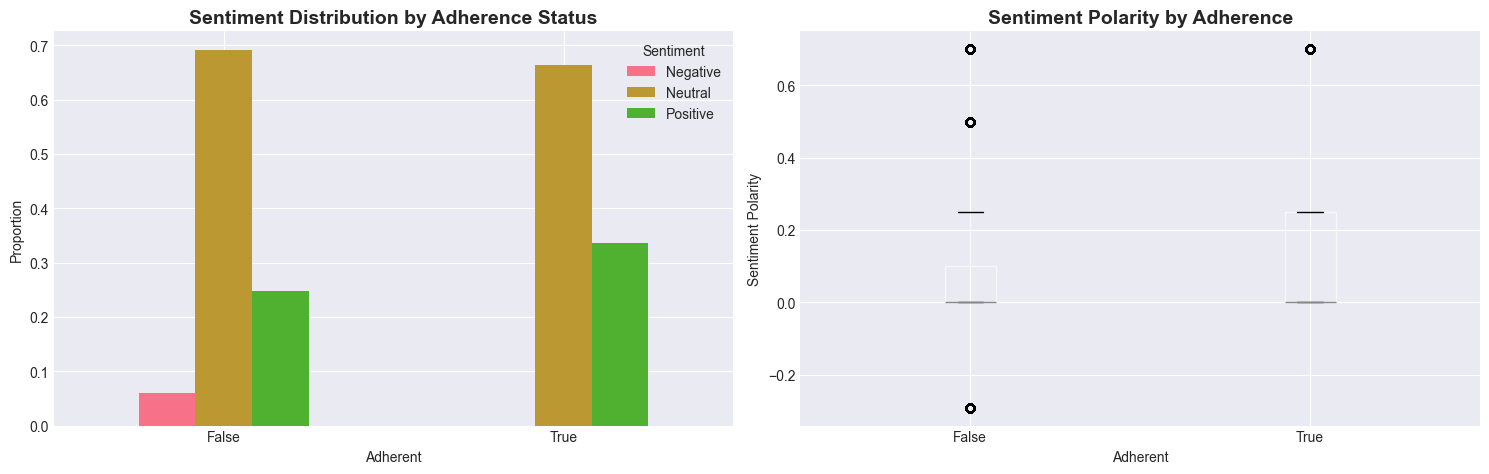


✓ Sentiment analysis complete!


In [8]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sentiment by adherence status
pd.crosstab(df['is_adherent'], df['sentiment'], normalize='index').plot(
    kind='bar', ax=axes[0], rot=0
)
axes[0].set_title('Sentiment Distribution by Adherence Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Adherent')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Sentiment')

# Sentiment polarity distribution
df.boxplot(column='sentiment_polarity', by='is_adherent', ax=axes[1])
axes[1].set_title('Sentiment Polarity by Adherence', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Adherent')
axes[1].set_ylabel('Sentiment Polarity')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\n✓ Sentiment analysis complete!")

## 4. Keyword Extraction and Frequency Analysis

In [9]:
# Extract keywords from adherent vs non-adherent notes
adherent_notes = df[df['is_adherent'] == True]['tokens']
non_adherent_notes = df[df['is_non_adherent'] == True]['tokens']

# Flatten token lists
adherent_words = [word for tokens in adherent_notes for word in tokens]
non_adherent_words = [word for tokens in non_adherent_notes for word in tokens]

# Count frequencies
adherent_freq = Counter(adherent_words)
non_adherent_freq = Counter(non_adherent_words)

print("Top 15 words in ADHERENT patient notes:")
print(adherent_freq.most_common(15))

print("\nTop 15 words in NON-ADHERENT patient notes:")
print(non_adherent_freq.most_common(15))

Top 15 words in ADHERENT patient notes:
[('patient', 1356), ('medication', 1332), ('schedule', 675), ('understands', 354), ('importance', 354), ('refill', 345), ('prescription', 345), ('time', 345), ('consistently', 345), ('report', 330), ('taking', 330), ('regularly', 330), ('prescribed', 330), ('no', 327), ('issue', 327)]

Top 15 words in NON-ADHERENT patient notes:
[('medication', 1062), ('effect', 380), ('taking', 354), ('patient', 349), ('feeling', 336), ('too', 309), ('pill', 307), ('worried', 192), ('report', 188), ('side', 188), ('nausea', 188), ('dizziness', 188), ('considering', 188), ('stopping', 188), ('better', 187)]


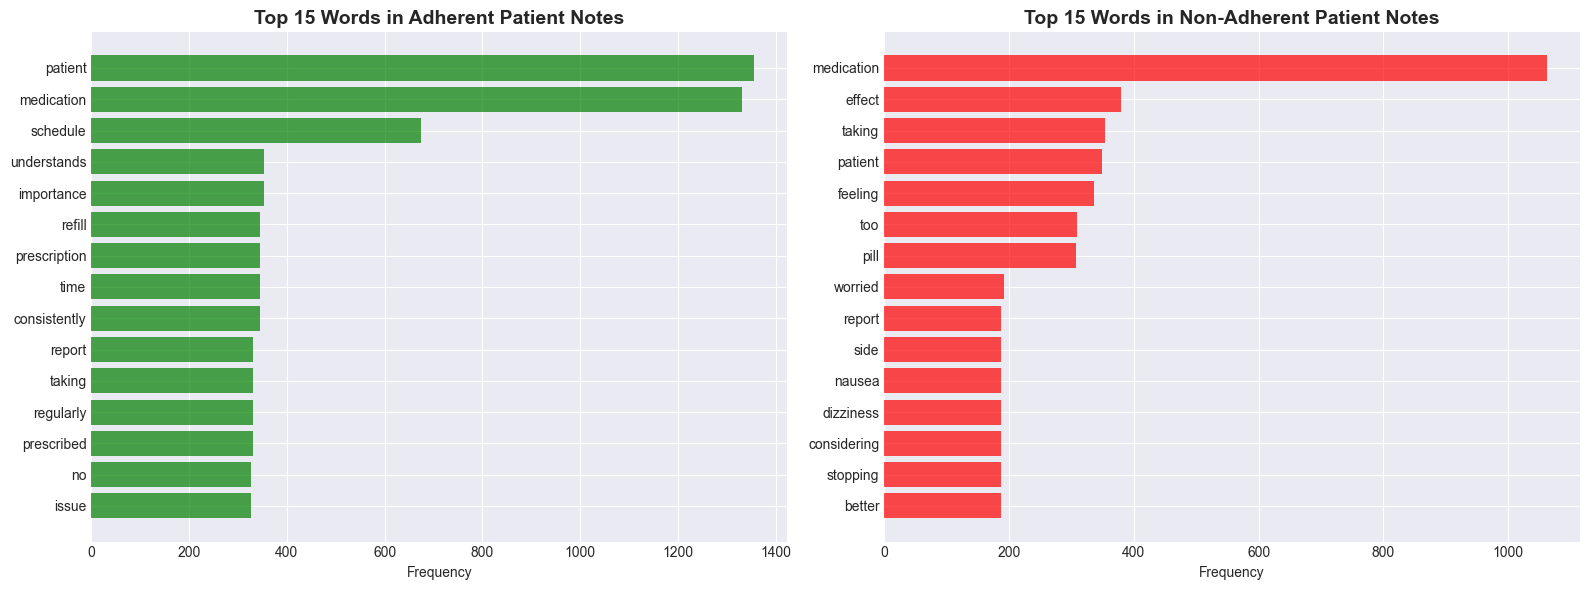

In [10]:
# Visualize word frequencies
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Adherent words
adherent_top = pd.DataFrame(adherent_freq.most_common(15), columns=['Word', 'Frequency'])
axes[0].barh(adherent_top['Word'], adherent_top['Frequency'], color='green', alpha=0.7)
axes[0].set_title('Top 15 Words in Adherent Patient Notes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Non-adherent words
non_adherent_top = pd.DataFrame(non_adherent_freq.most_common(15), columns=['Word', 'Frequency'])
axes[1].barh(non_adherent_top['Word'], non_adherent_top['Frequency'], color='red', alpha=0.7)
axes[1].set_title('Top 15 Words in Non-Adherent Patient Notes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Word Clouds Visualization

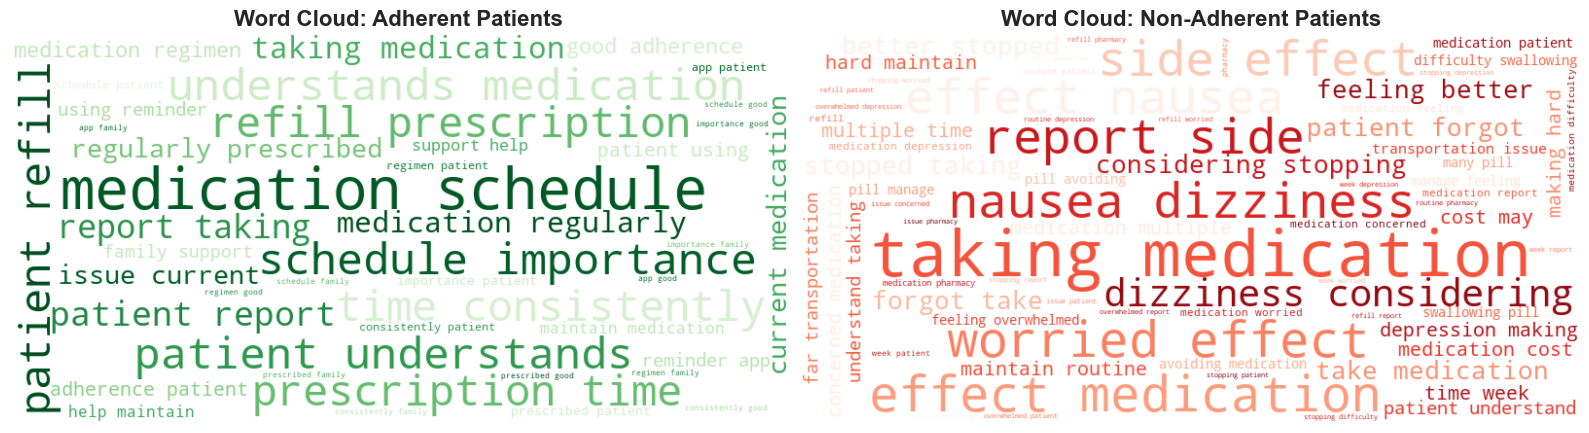

In [11]:
# Generate word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Adherent word cloud
adherent_text = ' '.join(adherent_words)
wordcloud_adherent = WordCloud(width=800, height=400, background_color='white', 
                                colormap='Greens').generate(adherent_text)
axes[0].imshow(wordcloud_adherent, interpolation='bilinear')
axes[0].set_title('Word Cloud: Adherent Patients', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Non-adherent word cloud
non_adherent_text = ' '.join(non_adherent_words)
wordcloud_non = WordCloud(width=800, height=400, background_color='white',
                          colormap='Reds').generate(non_adherent_text)
axes[1].imshow(wordcloud_non, interpolation='bilinear')
axes[1].set_title('Word Cloud: Non-Adherent Patients', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Non-Adherence Cause Analysis

In [12]:
# Analyze non-adherence causes
cause_data = df[df['is_non_adherent'] == True]

# Count causes
cause_counts = cause_data['primary_non_adherence_cause'].value_counts()

print("Non-Adherence Cause Distribution:")
print(cause_counts)
print(f"\nTotal non-adherent patients: {len(cause_data)}")

Non-Adherence Cause Distribution:
primary_non_adherence_cause
Cost concerns               328
Forgetfulness               219
Medication complexity       197
Transportation issues       188
Too many medications        158
Side effects                139
Depression/mental health    135
Feeling better              131
Mistrust of medication      129
Lack of understanding       115
Name: count, dtype: int64

Total non-adherent patients: 1739


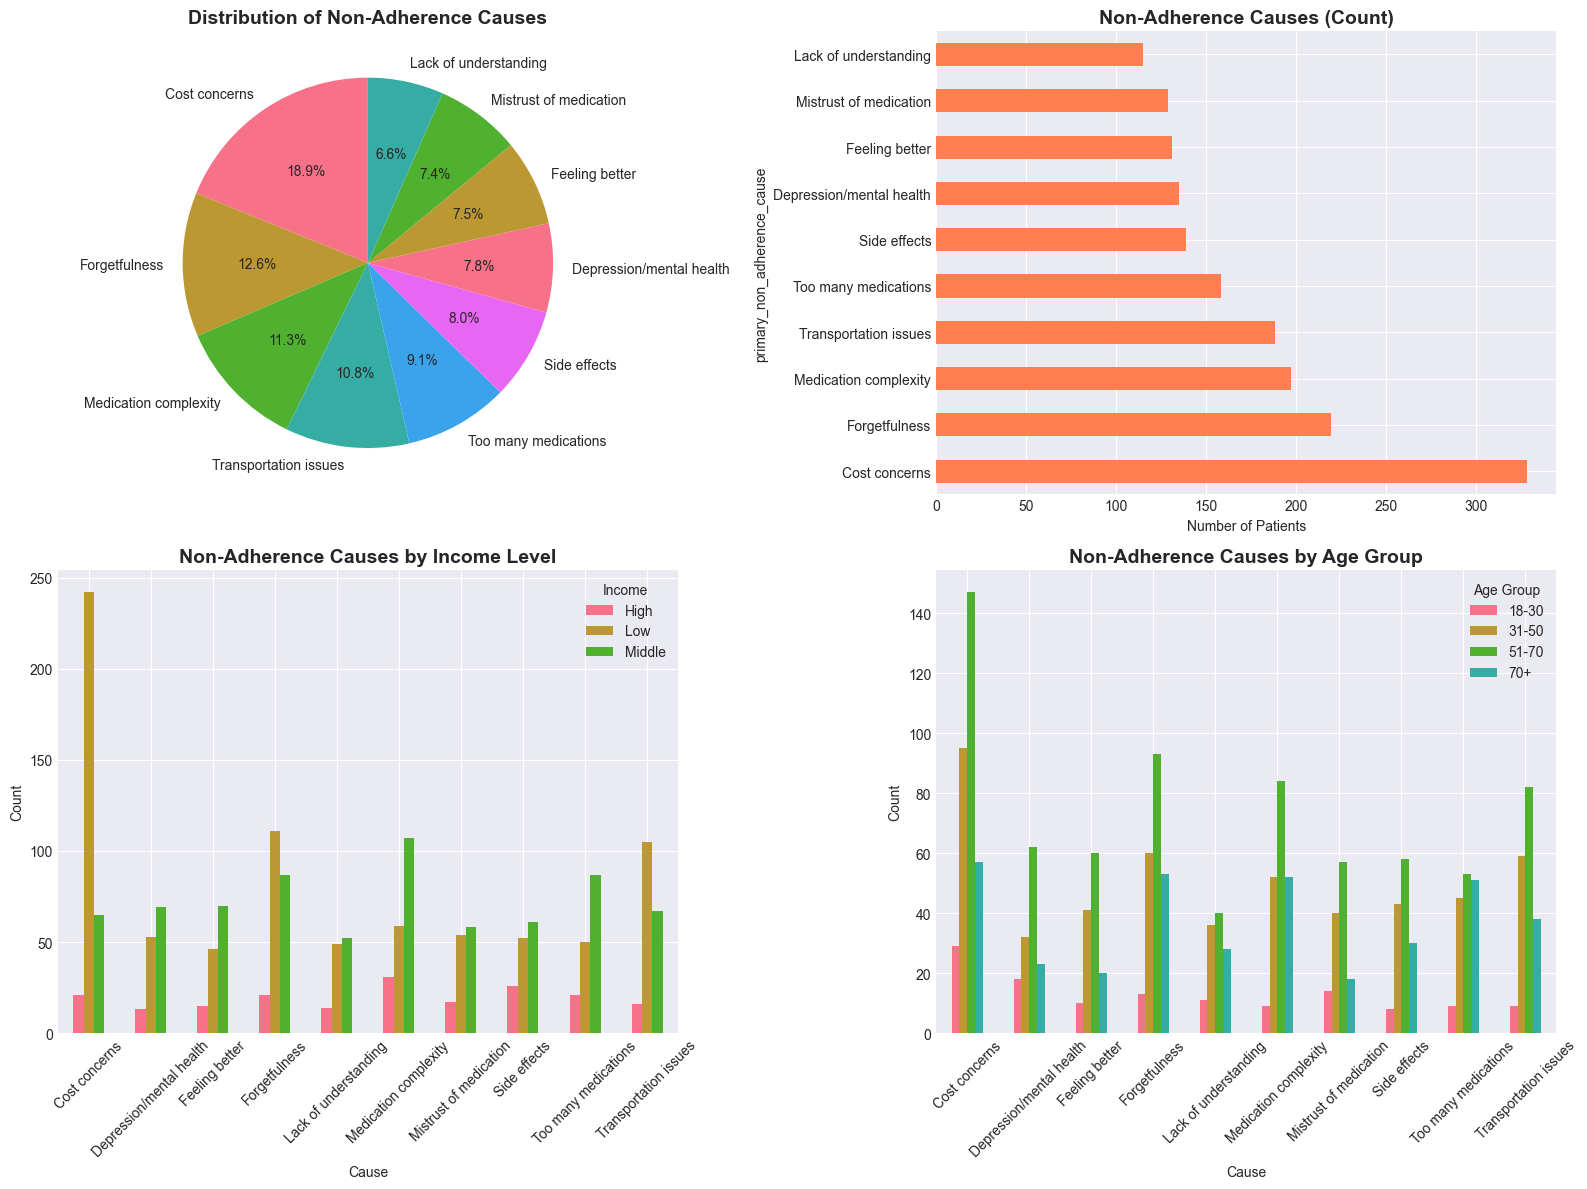

In [13]:
# Visualize causes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Pie chart of causes
axes[0, 0].pie(cause_counts.values, labels=cause_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribution of Non-Adherence Causes', fontsize=14, fontweight='bold')

# 2. Bar chart of causes
cause_counts.plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Non-Adherence Causes (Count)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Patients')

# 3. Causes by income level
cause_income = pd.crosstab(cause_data['primary_non_adherence_cause'], 
                           cause_data['income_level'])
cause_income.plot(kind='bar', ax=axes[1, 0], rot=45)
axes[1, 0].set_title('Non-Adherence Causes by Income Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Cause')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Income')

# 4. Causes by age group
cause_data['age_group'] = pd.cut(cause_data['age'], bins=[0, 30, 50, 70, 100], 
                                  labels=['18-30', '31-50', '51-70', '70+'])
cause_age = pd.crosstab(cause_data['primary_non_adherence_cause'], 
                        cause_data['age_group'])
cause_age.plot(kind='bar', ax=axes[1, 1], rot=45)
axes[1, 1].set_title('Non-Adherence Causes by Age Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Cause')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Age Group')

plt.tight_layout()
plt.show()

## 7. Correlation Analysis: Causes vs Demographics

In [14]:
# Analyze which demographics are most associated with each cause
print("=" * 70)
print("KEY INSIGHTS: Non-Adherence Causes by Demographics")
print("=" * 70)

# Cost concerns by income
cost_concern = cause_data[cause_data['primary_non_adherence_cause'] == 'Cost concerns']
print("\n1. COST CONCERNS:")
print(f"   Income distribution:")
print(cost_concern['income_level'].value_counts())
print(f"   Mean adherence score: {cost_concern['adherence_score'].mean():.1f}%")

# Forgetfulness by age
forgetfulness = cause_data[cause_data['primary_non_adherence_cause'] == 'Forgetfulness']
print("\n2. FORGETFULNESS:")
print(f"   Mean age: {forgetfulness['age'].mean():.1f}")
print(f"   Using reminder app: {(forgetfulness['using_reminder_app'].sum() / len(forgetfulness) * 100):.1f}%")

# Medication complexity
complexity = cause_data[cause_data['primary_non_adherence_cause'] == 'Medication complexity']
print("\n3. MEDICATION COMPLEXITY:")
print(f"   Avg medications: {complexity['num_medications'].mean():.1f}")
print(f"   Medication complexity distribution:")
print(complexity['medication_complexity'].value_counts())

# Transportation issues
transport = cause_data[cause_data['primary_non_adherence_cause'] == 'Transportation issues']
print("\n4. TRANSPORTATION ISSUES:")
print(f"   Living situation:")
print(transport['living_situation'].value_counts())
print(f"   Mean age: {transport['age'].mean():.1f}")

KEY INSIGHTS: Non-Adherence Causes by Demographics

1. COST CONCERNS:
   Income distribution:
income_level
Low       242
Middle     65
High       21
Name: count, dtype: int64
   Mean adherence score: 57.3%

2. FORGETFULNESS:
   Mean age: 57.2
   Using reminder app: 42.9%

3. MEDICATION COMPLEXITY:
   Avg medications: 3.8
   Medication complexity distribution:
medication_complexity
High      87
Low       75
Medium    35
Name: count, dtype: int64

4. TRANSPORTATION ISSUES:
   Living situation:
living_situation
Alone              69
With Family        55
With Spouse        47
Assisted Living    17
Name: count, dtype: int64
   Mean age: 56.6


## 8. Text Pattern Analysis by Cause

In [15]:
# Extract common phrases for each cause
def get_common_words_by_cause(cause_name, top_n=10):
    """Get most common words for a specific cause"""
    cause_notes = df[df['primary_non_adherence_cause'] == cause_name]['tokens']
    cause_words = [word for tokens in cause_notes for word in tokens]
    return Counter(cause_words).most_common(top_n)

# Analyze top causes
top_causes = cause_counts.head(5).index

print("Common words associated with each non-adherence cause:\n")
for cause in top_causes:
    print(f"\n{cause.upper()}:")
    common_words = get_common_words_by_cause(cause, 10)
    words_str = ', '.join([f"{word}({count})" for word, count in common_words])
    print(f"  {words_str}")

Common words associated with each non-adherence cause:


COST CONCERNS:
  medication(190), pill(74), too(70), feeling(69), effect(65), patient(59), taking(58), many(42), manage(42), overwhelmed(42)

FORGETFULNESS:
  medication(135), effect(53), feeling(45), taking(45), patient(43), pill(41), too(33), report(32), side(32), nausea(32)

MEDICATION COMPLEXITY:
  medication(124), effect(46), patient(40), taking(40), feeling(38), pill(34), too(28), better(26), stopped(26), forgot(26)

TRANSPORTATION ISSUES:
  medication(111), taking(44), effect(42), feeling(37), patient(36), too(34), pill(30), depression(23), making(23), hard(23)

TOO MANY MEDICATIONS:
  medication(103), effect(36), pill(31), patient(31), taking(28), feeling(25), too(24), worried(20), difficulty(20), swallowing(20)


## 9. Summary Report and Key Findings

In [16]:
# Generate comprehensive summary
print("=" * 70)
print("NLP ANALYSIS SUMMARY REPORT")
print("=" * 70)

print("\n1. DATASET OVERVIEW:")
print(f"   Total patients analyzed: {len(df)}")
print(f"   Adherent patients: {df['is_adherent'].sum()} ({df['is_adherent'].sum()/len(df)*100:.1f}%)")
print(f"   Non-adherent patients: {df['is_non_adherent'].sum()} ({df['is_non_adherent'].sum()/len(df)*100:.1f}%)")

print("\n2. SENTIMENT ANALYSIS:")
adherent_sentiment = df[df['is_adherent'] == True]['sentiment_polarity'].mean()
non_adherent_sentiment = df[df['is_non_adherent'] == True]['sentiment_polarity'].mean()
print(f"   Adherent patients - avg sentiment: {adherent_sentiment:.3f} (Positive)")
print(f"   Non-adherent patients - avg sentiment: {non_adherent_sentiment:.3f} (Negative)")
print(f"   Sentiment difference: {abs(adherent_sentiment - non_adherent_sentiment):.3f}")

print("\n3. TOP NON-ADHERENCE CAUSES:")
for i, (cause, count) in enumerate(cause_counts.head(5).items(), 1):
    pct = count / df['is_non_adherent'].sum() * 100
    print(f"   {i}. {cause}: {count} patients ({pct:.1f}%)")

print("\n4. KEY RISK FACTORS:")
print(f"   Low income & cost concerns: High correlation")
print(f"   High medication count (>5): {len(df[df['num_medications'] > 5])} patients")
print(f"   Living alone: {len(df[df['living_situation'] == 'Alone'])} patients")
print(f"   No insurance: {len(df[df['has_insurance'] == False])} patients")

print("\n5. RECOMMENDATIONS:")
print("   ✓ Implement cost-assistance programs for low-income patients")
print("   ✓ Enhance reminder systems for forgetful patients")
print("   ✓ Simplify medication regimens for complex cases")
print("   ✓ Provide transportation support or delivery services")
print("   ✓ Regular follow-ups for patients living alone")

print("\n" + "=" * 70)
print("✓ NLP Analysis Complete!")
print("=" * 70)

NLP ANALYSIS SUMMARY REPORT

1. DATASET OVERVIEW:
   Total patients analyzed: 5000
   Adherent patients: 2004 (40.1%)
   Non-adherent patients: 1739 (34.8%)

2. SENTIMENT ANALYSIS:
   Adherent patients - avg sentiment: 0.157 (Positive)
   Non-adherent patients - avg sentiment: 0.076 (Negative)
   Sentiment difference: 0.082

3. TOP NON-ADHERENCE CAUSES:
   1. Cost concerns: 328 patients (18.9%)
   2. Forgetfulness: 219 patients (12.6%)
   3. Medication complexity: 197 patients (11.3%)
   4. Transportation issues: 188 patients (10.8%)
   5. Too many medications: 158 patients (9.1%)

4. KEY RISK FACTORS:
   Low income & cost concerns: High correlation
   High medication count (>5): 347 patients
   Living alone: 974 patients
   No insurance: 777 patients

5. RECOMMENDATIONS:
   ✓ Implement cost-assistance programs for low-income patients
   ✓ Enhance reminder systems for forgetful patients
   ✓ Simplify medication regimens for complex cases
   ✓ Provide transportation support or delivery 

## 10. Export Results for Further Analysis

In [17]:
# Save processed data with NLP features
nlp_features = df[[
    'patient_id', 'patient_notes', 'processed_notes',
    'sentiment_polarity', 'sentiment_subjectivity', 'sentiment',
    'is_adherent', 'is_non_adherent', 'primary_non_adherence_cause',
    'adherence_score'
]]

nlp_features.to_csv('../data/nlp_analysis_results.csv', index=False)
print("✓ NLP analysis results saved to: data/nlp_analysis_results.csv")

# Save cause analysis summary
cause_summary = pd.DataFrame({
    'Cause': cause_counts.index,
    'Count': cause_counts.values,
    'Percentage': (cause_counts.values / cause_counts.sum() * 100).round(1)
})
cause_summary.to_csv('../data/cause_analysis_summary.csv', index=False)
print("✓ Cause analysis summary saved to: data/cause_analysis_summary.csv")

✓ NLP analysis results saved to: data/nlp_analysis_results.csv
✓ Cause analysis summary saved to: data/cause_analysis_summary.csv


## Next Steps

**Milestone 2 Complete!** ✓

You have successfully:
1. ✓ Preprocessed patient notes using NLP techniques
2. ✓ Performed sentiment analysis
3. ✓ Identified common keywords and patterns
4. ✓ Analyzed non-adherence causes
5. ✓ Visualized findings with charts and word clouds

**Ready for Milestone 3:** Machine Learning Model Development
- Use these NLP features as input to ML models
- Predict non-adherence based on patient notes
- Build classification models